# Tutorial evaluating

### Setting up environment

In [23]:
import sys
import os
code_folder = "C:/Users/bpeng/OneDrive - J. Craig Venter Institute/Documents/Github/NSForest"
sys.path.insert(0, os.path.abspath(code_folder))
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import nsforest as ns
from nsforest import utils
from nsforest import preprocessing as pp
from nsforest import nsforesting
from nsforest import evaluating as ev
from nsforest import plotting as pl

### Data Exploration

#### Loading h5ad AnnData file

In [2]:
data_folder = "../demo_data/"
file = data_folder + "adata_layer1.h5ad"
adata = sc.read_h5ad(file)
adata

AnnData object with n_obs × n_vars = 871 × 16497
    obs: 'cluster'

#### Defining `cluster_header` as cell type annotation. 

**Note:** Some datasets have multiple annotations per sample (ex. "broad_cell_type" and "granular_cell_type"). NS-Forest can be run on multiple `cluster_header`'s. Combining the parent and child markers may improve classification results. 

In [3]:
cluster_header = "cluster"

#### Defining `output_folder` for saving results

In [4]:
output_folder = "../outputs_layer1/"

#### Looking at sample labels

In [5]:
adata.obs_names

Index(['A01_1_Nuclei_NeuNP_H200_1025_MTG_layer1_BCH9',
       'A01_BCH3_1NeuNP_H200.1030_MTG_Layer_1',
       'A02_BCH1_1NeuNP_H200.1025_MTG_layer_1',
       'A03_1_Nuclei_NeuNP_H200_1025_MTG_layer1_BCH9',
       'A04_1_Nuclei_NeuNP_H200_1025_MTG_layer1_BCH9',
       'A04_BCH1_1NeuNP_H200.1025_MTG_layer_1',
       'A04_BCH3_1NeuNP_H200.1030_MTG_Layer_1',
       'A05_1_Nuclei_NeuNP_H200_1025_MTG_layer1_BCH9',
       'A05_BCH1_1NeuNP_H200.1025_MTG_layer_1',
       'A05_BCH3_1NeuNP_H200.1030_MTG_Layer_1',
       ...
       'P09_1_Nuclei_NeuNN_H200_1025_MTG_layer1_BCH7',
       'P09_1_Nuclei_NeuNN_H200_1025_MTG_layer1_BCH9',
       'P09_1_Nuclei_NeuNN_H200_1030_MTG_layer1_BCH8',
       'P09_BCH1_1NeuNN_H200.1025_MTG_layer_1',
       'P10_1_Nuclei_NeuNN_H200_1025_MTG_layer1_BCH6',
       'P10_1_Nuclei_NeuNN_H200_1025_MTG_layer1_BCH9',
       'P10_BCH1_1NeuNN_H200.1025_MTG_layer_1',
       'P11_1_Nuclei_NeuNN_H200_1025_MTG_layer1_BCH7',
       'P11_1_Nuclei_NeuNN_H200_1025_MTG_layer1_BCH9',


#### Looking at genes

**Note:** `adata.var_names` must be unique. If there is a problem, usually it can be solved by assigning `adata.var.index = adata.var["ensembl_id"]`. 

In [6]:
adata.var_names

Index(['A1CF', 'A2M', 'A2M_AS1', 'A2ML1', 'A2ML1_AS1', 'A2MP1', 'A3GALT2',
       'A4GALT', 'AAAS', 'AACS',
       ...
       'ZUFSP', 'ZW10', 'ZWILCH', 'ZWINT', 'ZXDC', 'ZYG11A', 'ZYG11B', 'ZYX',
       'ZZEF1', 'ZZZ3'],
      dtype='object', length=16497)

#### Checking cell annotation sizes 

**Note:** Some datasets are too large and need to be downsampled to be run through the pipeline. When downsampling, be sure to have all the granular cluster annotations represented. 

In [7]:
pd.DataFrame(adata.obs[cluster_header].value_counts()).reset_index()

,cluster,count
0,e1_e299_SLC17A7_L5b_Cdh13,299
1,i1_i90_COL5A2_Ndnf_Car4,90
2,i2_i77_LHX6_Sst_Cbln4,77
3,i3_i56_BAGE2_Ndnf_Cxcl14,56
4,i4_i54_MC4R_Ndnf_Cxcl14,54
5,g1_g48_GLI3_Astro_Gja1,48
6,i5_i47_TRPC3_Ndnf_Car4,47
7,i6_i44_GPR149_Vip_Mybpc1,44
8,i7_i31_CLMP_Ndnf_Cxcl14,31
9,g2_g27_APBB1IP_Micro_Ctss,27


### Preprocessing

#### Generating scanpy dendrogram

**Note:** Only run if there is no pre-defined dendrogram order. This step can still be run with no effects, but the runtime may increase. 

Dendrogram order is stored in `adata.uns["dendrogram_cluster"]["categories_ordered"]`. 

Saving dendrogram as...
../outputs_layer1/_cluster.png


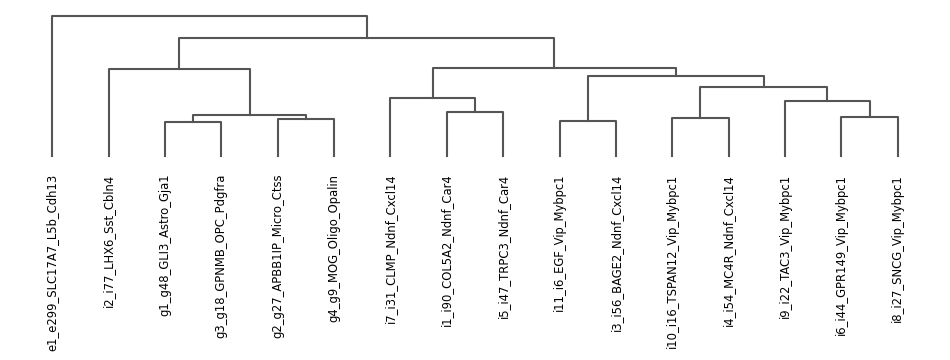

In [8]:
ns.pp.dendrogram(adata, cluster_header, save = True, output_folder = output_folder, outputfilename_suffix = cluster_header)

### Evaluating input marker list

#### Getting marker list in dictionary format: {cluster: marker_list}

In [9]:
markers = pd.read_csv("../demo_data/marker_list.csv")
markers_dict = utils.prepare_markers(markers, "clusterName", "markers")
markers_dict

{'e1_e299_SLC17A7_L5b_Cdh13': ['SLC17A7', 'CDH13'],
 'g1_g48_GLI3_Astro_Gja1': ['GLI3', 'GJA1'],
 'g2_g27_APBB1IP_Micro_Ctss': ['APBB1IP', 'CTSS'],
 'g3_g18_GPNMB_OPC_Pdgfra': ['GPNMB', 'PDGFRA'],
 'g4_g9_MOG_Oligo_Opalin': ['MOG', 'OPALIN'],
 'i10_i16_TSPAN12_Vip_Mybpc1': ['TSPAN12', 'VIP', 'MYBPC1'],
 'i11_i6_EGF_Vip_Mybpc1': ['EGF', 'VIP', 'MYBPC1'],
 'i1_i90_COL5A2_Ndnf_Car4': ['COL5A2', 'NDNF', 'CAR4'],
 'i2_i77_LHX6_Sst_Cbln4': ['LHX6', 'SST', 'CBLN4'],
 'i3_i56_BAGE2_Ndnf_Cxcl14': ['BAGE2', 'NDNF', 'CXCL14'],
 'i4_i54_MC4R_Ndnf_Cxcl14': ['MC4R', 'NDNF', 'CXCL14'],
 'i5_i47_TRPC3_Ndnf_Car4': ['TRPC3', 'NDNF', 'CAR4'],
 'i6_i44_GPR149_Vip_Mybpc1': ['GPR149', 'VIP', 'MYBPC1'],
 'i7_i31_CLMP_Ndnf_Cxcl14': ['CLMP', 'NDNF', 'CXCL14'],
 'i8_i27_SNCG_Vip_Mybpc1': ['SNCG', 'VIP', 'MYBPC1'],
 'i9_i22_TAC3_Vip_Mybpc1': ['TAC3', 'VIP', 'MYBPC1']}

In [10]:
outputfilename_prefix = "marker_eval"
evaluation_results = ev.DecisionTree(adata, cluster_header, markers_dict, combinations = False, use_mean = False, 
                                     save_supplementary = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)

Running NS-Forest version 4.1

Preparing data...
--- 0.005995512008666992 seconds ---

Number of clusters to evaluate: 16
1 out of 16:
	e1_e299_SLC17A7_L5b_Cdh13
	marker genes to be evaluated: ['SLC17A7', 'CDH13']
	fbeta: 0.945
	precision: 0.988
	recall: 0.806
2 out of 16:
	g1_g48_GLI3_Astro_Gja1
	marker genes to be evaluated: ['GLI3', 'GJA1']
	fbeta: 0.893
	precision: 1.0
	recall: 0.625
3 out of 16:
	g2_g27_APBB1IP_Micro_Ctss
	marker genes to be evaluated: ['APBB1IP', 'CTSS']
	fbeta: 0.385
	precision: 1.0
	recall: 0.111
4 out of 16:
	g3_g18_GPNMB_OPC_Pdgfra
	marker genes to be evaluated: ['GPNMB', 'PDGFRA']
	fbeta: 0.929
	precision: 1.0
	recall: 0.722
5 out of 16:
	g4_g9_MOG_Oligo_Opalin
	marker genes to be evaluated: ['MOG', 'OPALIN']
	fbeta: 0.909
	precision: 1.0
	recall: 0.667
6 out of 16:
	i10_i16_TSPAN12_Vip_Mybpc1
	marker genes to be evaluated: ['TSPAN12', 'VIP', 'MYBPC1']
	fbeta: 0.469
	precision: 0.75
	recall: 0.188
7 out of 16:
	i11_i6_EGF_Vip_Mybpc1
	marker genes to be evalu

Calculating medians per cluster: 100%|██████████| 16/16 [00:00<00:00, 246.18it/s]

Saving supplementary table as...
../outputs_layer1/marker_eval_markers_onTarget_supp.csv
Saving supplementary table as...
../outputs_layer1/marker_eval_markers_onTarget.csv


In [11]:
evaluation_results

,software_version,cluster_header,clusterName,clusterSize,f_score,precision,recall,TN,FP,FN,TP,marker_count,markers,onTarget
0,4.1,cluster,e1_e299_SLC17A7_L5b_Cdh13,299,0.945098,0.987705,0.806020,569,3,58,241,2,"[SLC17A7, CDH13]",0.548527
1,4.1,cluster,g1_g48_GLI3_Astro_Gja1,48,0.892857,1.000000,0.625000,823,0,18,30,2,"[GLI3, GJA1]",0.854088
2,4.1,cluster,g2_g27_APBB1IP_Micro_Ctss,27,0.384615,1.000000,0.111111,844,0,24,3,2,"[APBB1IP, CTSS]",0.955321
3,4.1,cluster,g3_g18_GPNMB_OPC_Pdgfra,18,0.928571,1.000000,0.722222,853,0,5,13,2,"[GPNMB, PDGFRA]",0.680299
4,4.1,cluster,g4_g9_MOG_Oligo_Opalin,9,0.909091,1.000000,0.666667,862,0,3,6,2,"[MOG, OPALIN]",1.000000
5,4.1,cluster,i10_i16_TSPAN12_Vip_Mybpc1,16,0.468750,0.750000,0.187500,854,1,13,3,3,"[TSPAN12, VIP, MYBPC1]",0.209097
6,4.1,cluster,i11_i6_EGF_Vip_Mybpc1,6,0.000000,0.000000,0.000000,865,0,6,0,3,"[EGF, VIP, MYBPC1]",0.112842
7,4.1,cluster,i1_i90_COL5A2_Ndnf_Car4,90,0.879888,0.940299,0.700000,777,4,27,63,2,"[COL5A2, NDNF]",0.608344
8,4.1,cluster,i2_i77_LHX6_Sst_Cbln4,77,0.117647,1.000000,0.025974,794,0,75,2,3,"[LHX6, SST, CBLN4]",0.420224
9,4.1,cluster,i3_i56_BAGE2_Ndnf_Cxcl14,56,0.564516,0.823529,0.250000,812,3,42,14,3,"[BAGE2, NDNF, CXCL14]",0.103398


### Plotting scanpy dot plot, violin plot, matrix plot for input marker list

**Note:** Assign pre-defined dendrogram order here **or** use `adata.uns["dendrogram_" + cluster_header]["categories_ordered"]`. 

In [12]:
dendrogram = [] # custom dendrogram order
dendrogram = list(adata.uns["dendrogram_" + cluster_header]["categories_ordered"])
to_plot = evaluation_results.copy()
to_plot["clusterName"] = to_plot["clusterName"].astype("category")
to_plot["clusterName"] = to_plot["clusterName"].cat.set_categories(dendrogram)
to_plot = to_plot.sort_values("clusterName").reset_index(drop = True)
to_plot = to_plot.rename(columns = {"NSForest_markers": "markers"})

In [13]:
markers_dict = dict(zip(to_plot["clusterName"], to_plot["markers"]))
markers_dict

{'e1_e299_SLC17A7_L5b_Cdh13': ['SLC17A7', 'CDH13'],
 'i2_i77_LHX6_Sst_Cbln4': ['LHX6', 'SST', 'CBLN4'],
 'g1_g48_GLI3_Astro_Gja1': ['GLI3', 'GJA1'],
 'g3_g18_GPNMB_OPC_Pdgfra': ['GPNMB', 'PDGFRA'],
 'g2_g27_APBB1IP_Micro_Ctss': ['APBB1IP', 'CTSS'],
 'g4_g9_MOG_Oligo_Opalin': ['MOG', 'OPALIN'],
 'i7_i31_CLMP_Ndnf_Cxcl14': ['CLMP', 'NDNF', 'CXCL14'],
 'i1_i90_COL5A2_Ndnf_Car4': ['COL5A2', 'NDNF'],
 'i5_i47_TRPC3_Ndnf_Car4': ['TRPC3', 'NDNF'],
 'i11_i6_EGF_Vip_Mybpc1': ['EGF', 'VIP', 'MYBPC1'],
 'i3_i56_BAGE2_Ndnf_Cxcl14': ['BAGE2', 'NDNF', 'CXCL14'],
 'i10_i16_TSPAN12_Vip_Mybpc1': ['TSPAN12', 'VIP', 'MYBPC1'],
 'i4_i54_MC4R_Ndnf_Cxcl14': ['MC4R', 'NDNF', 'CXCL14'],
 'i9_i22_TAC3_Vip_Mybpc1': ['TAC3', 'VIP', 'MYBPC1'],
 'i6_i44_GPR149_Vip_Mybpc1': ['GPR149', 'VIP', 'MYBPC1'],
 'i8_i27_SNCG_Vip_Mybpc1': ['SNCG', 'VIP', 'MYBPC1']}

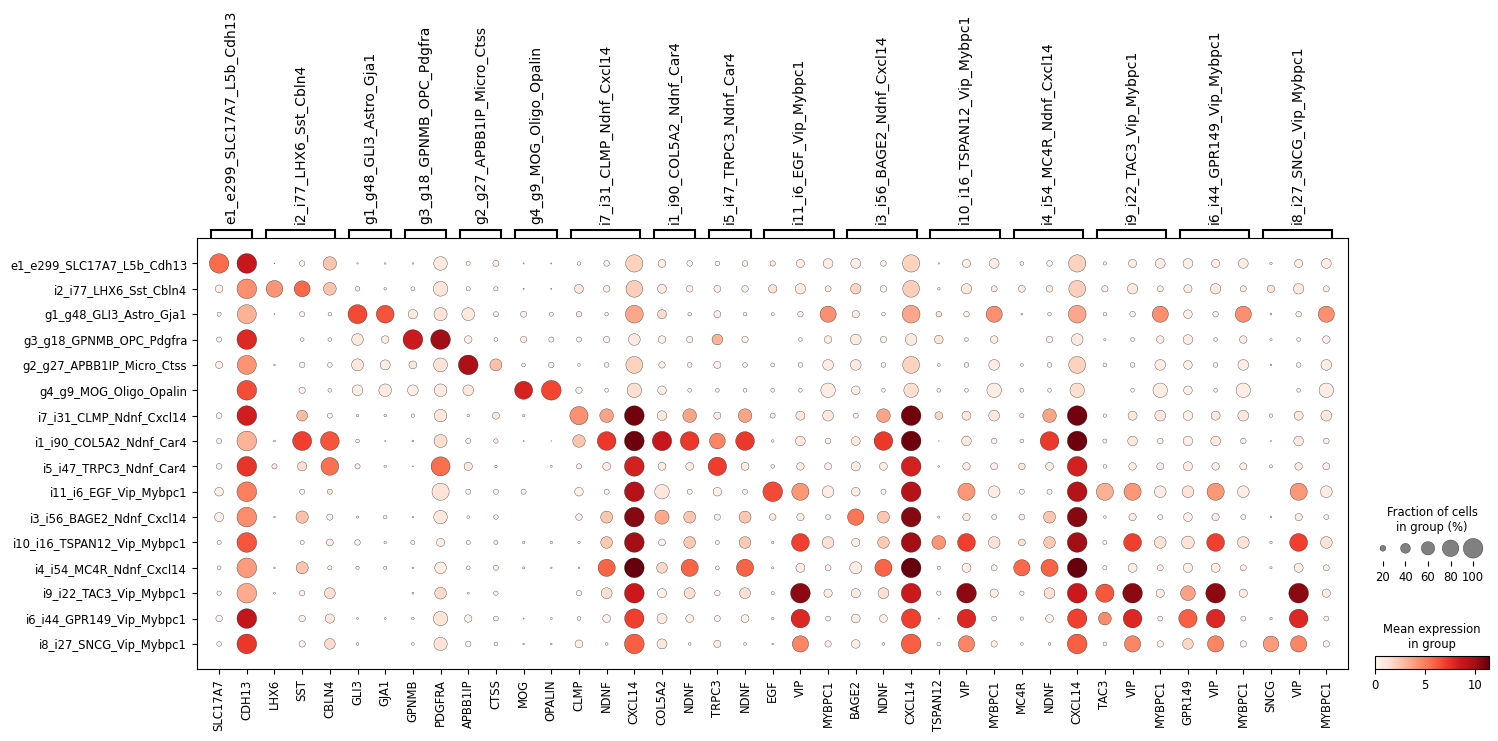

In [14]:
ns.pl.dotplot(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)

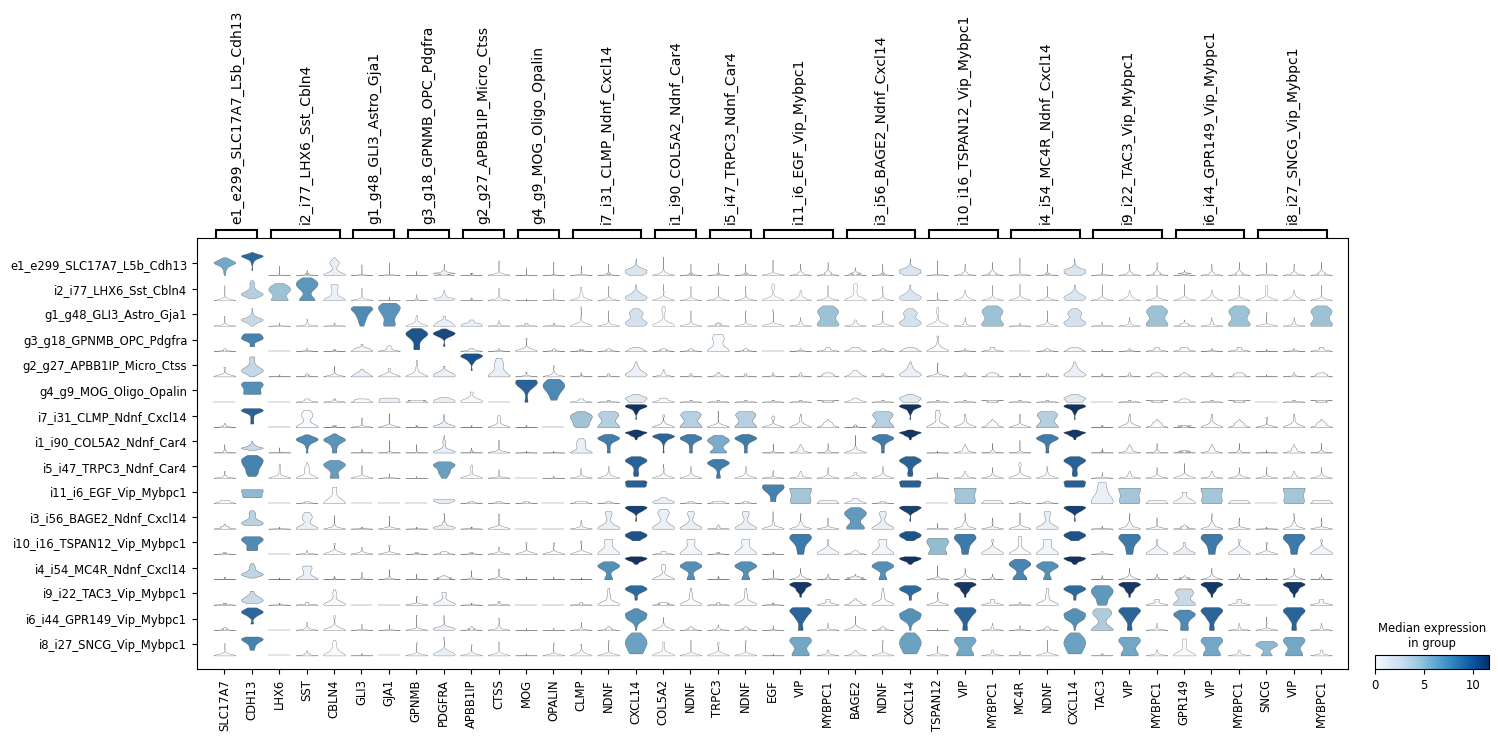

In [15]:
ns.pl.stackedviolin(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)

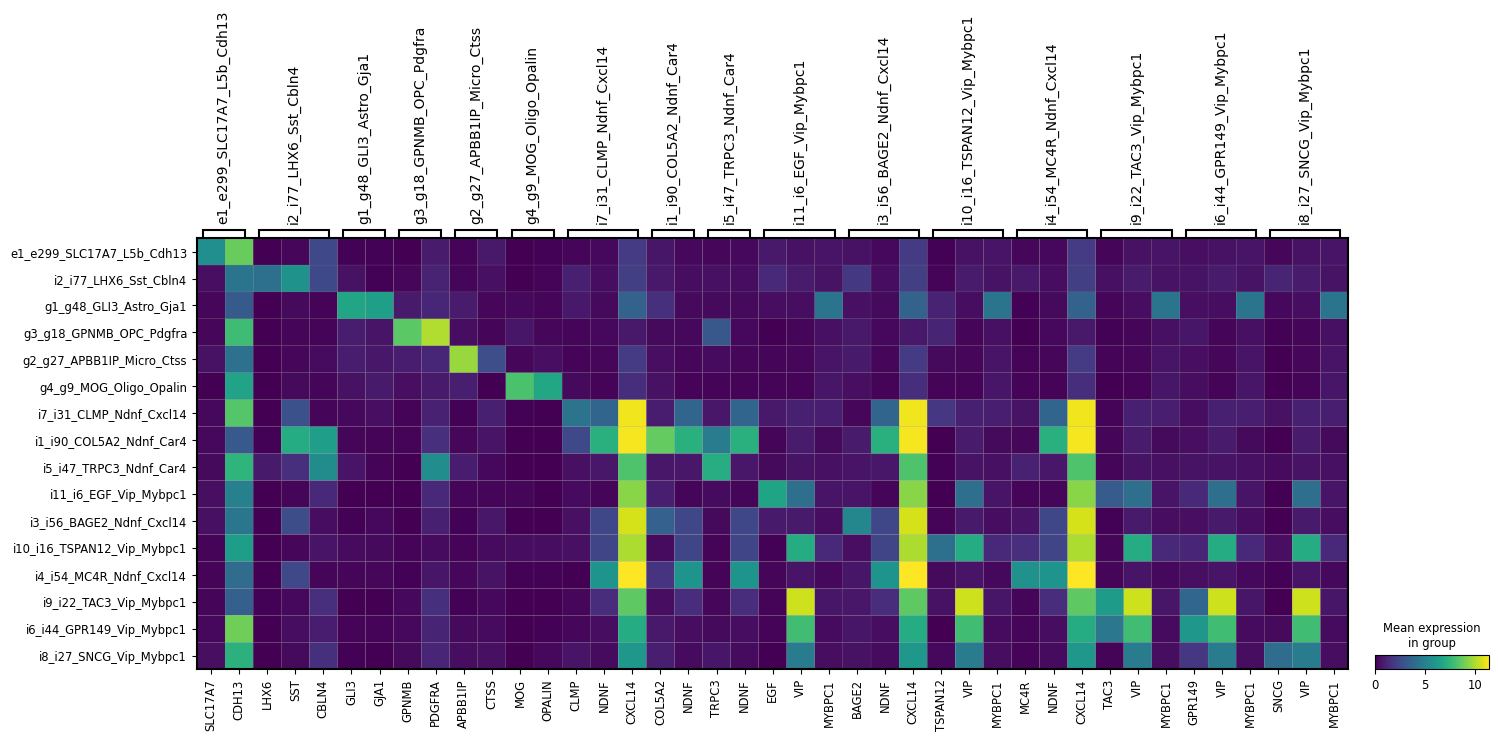

In [16]:
ns.pl.matrixplot(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)

#### Plotting classification metrics from NS-Forest results

Saving...
 ../outputs_layer1/marker_eval_boxplot_f_score_precision_recall_onTarget.html


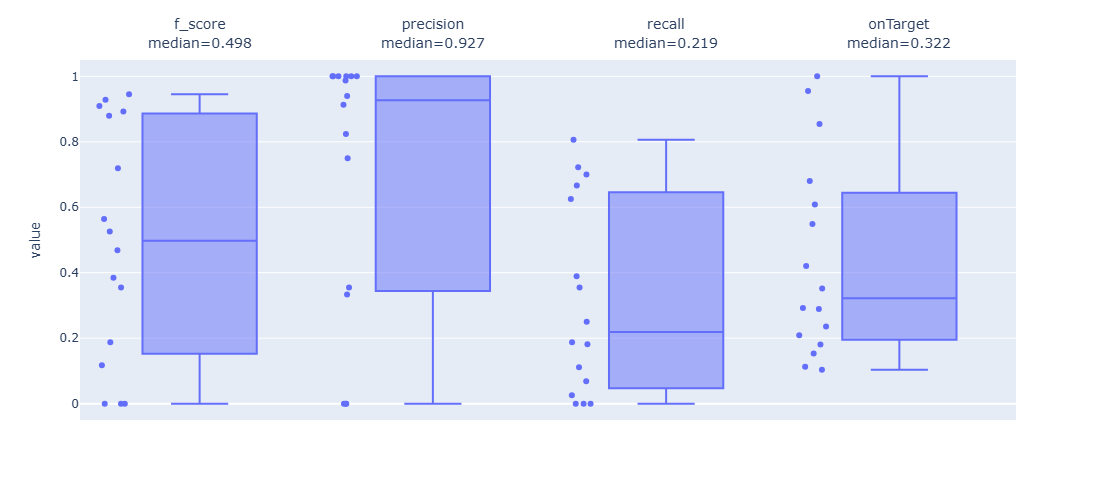

In [17]:
ns.pl.boxplot(evaluation_results, ["f_score", "precision", "recall", "onTarget"], save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)

#### Plotting individual classification metrics

Saving...
 ../outputs_layer1/marker_eval_boxplot_f_score.html


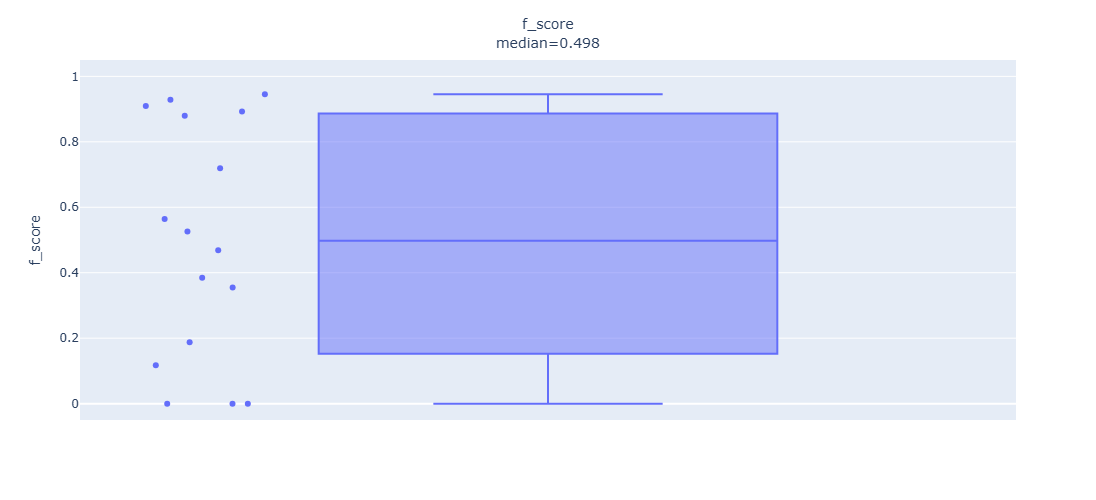

In [18]:
ns.pl.boxplot(evaluation_results, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)

#### Plotting metrics vs clusterSize

Saving...
 ../outputs_layer1/marker_eval_scatter_f_score.html


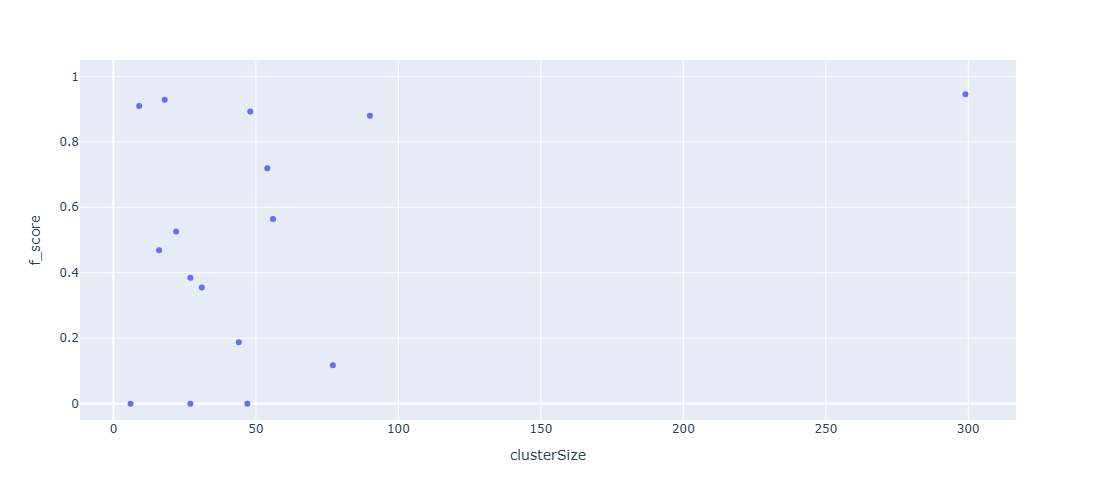

In [19]:
ns.pl.scatter_w_clusterSize(evaluation_results, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)

Saving...
 ../outputs_layer1/marker_eval_scatter_precision.html


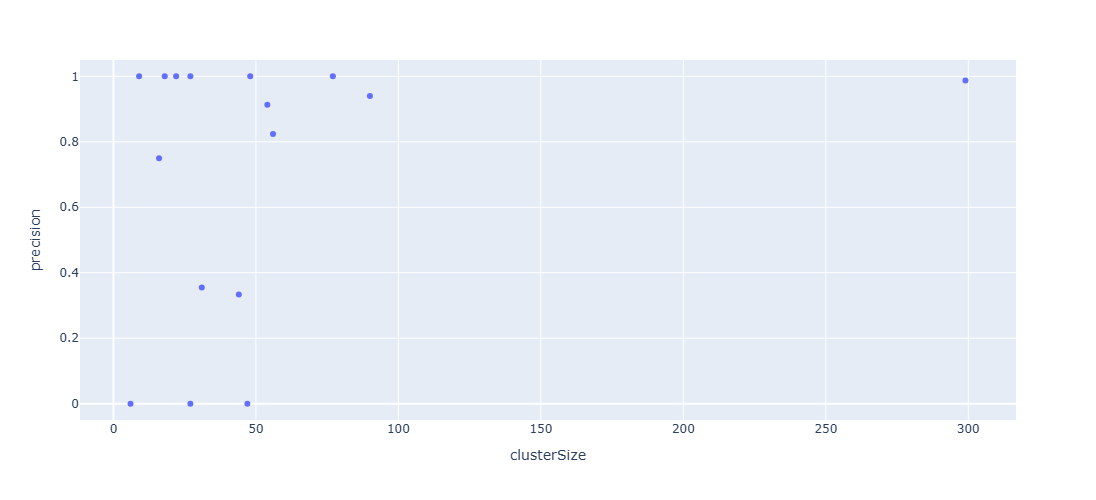

In [20]:
ns.pl.scatter_w_clusterSize(evaluation_results, "precision", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)

Saving...
 ../outputs_layer1/marker_eval_scatter_recall.html


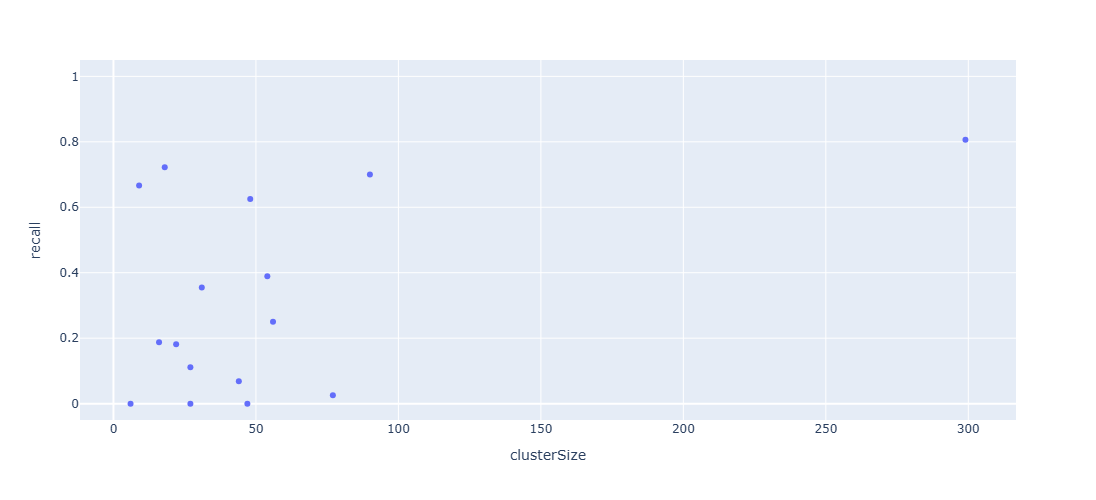

In [21]:
ns.pl.scatter_w_clusterSize(evaluation_results, "recall", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)

Saving...
 ../outputs_layer1/marker_eval_scatter_onTarget.html


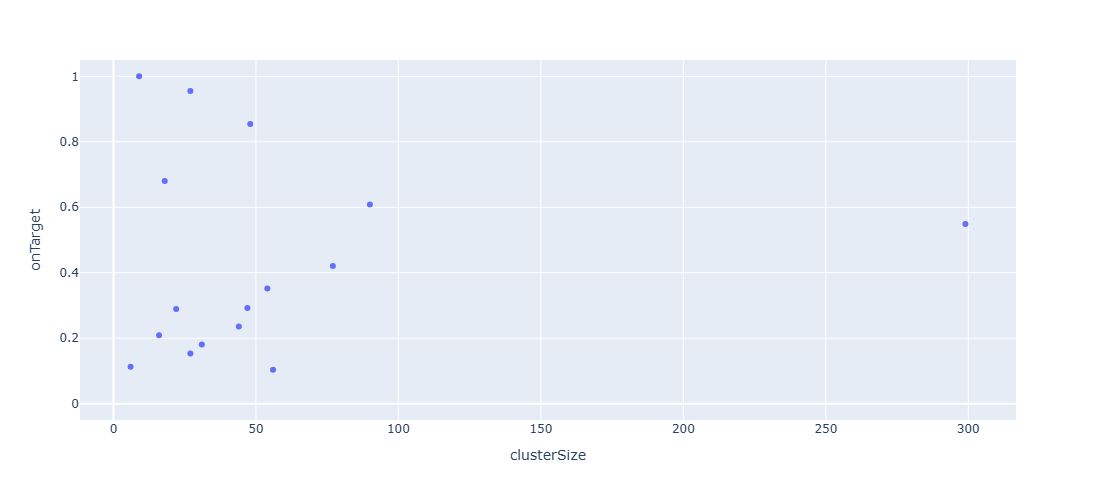

In [22]:
ns.pl.scatter_w_clusterSize(evaluation_results, "onTarget", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)